# Section 5: RQ3 — DBS Classification & Cross-Condition

| # | Figure | Count |
|---|--------|-------|
| 49 | Classification BA dot plot (prediction + forecast, 2×2: PSID/DPAD × z-as-behavior/z-as-neural) | 1 |
| 49a | Confusion matrix grids (4 separate figures: PSID/DPAD × behavioral/laplacian) | 4 |
| 51 | Cross-condition (flipped) forecast classification dot plot (PSID only, 1×2) | 1 |

**Archived** (results non-significant — see `thesis_figures/sec5/archive/`):
fig_050 ROC prediction, fig_050b ROC forecast, fig_052 prediction onset (t_cut), fig_052b forecast horizon decay.

In [1]:
import sys, os

os.chdir("/home/bobby/repos/latent-neural-dynamics-modeling")
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

from pathlib import Path
import csv
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

from sklearn.metrics import confusion_matrix as sk_confusion_matrix

from modules.style import (
    COLOR_DPAD,
    COLOR_PSID,
    apply_thesis_style,
    panel_label,
)
from modules.loaders import SESSIONS
from modules.sec2_common import SESSION_COLORS

apply_thesis_style()

OUT = Path("thesis_figures/sec5")
OUT.mkdir(parents=True, exist_ok=True)
results_root = Path("results").resolve()

## Classification spec lists

In [2]:
GROUP_ORDER: Tuple[str, ...] = ("xp", "xp_1", "xp_2", "xp_with_dbs")
GROUP_SHORT: Dict[str, str] = {
    "xp": "Xp",
    "xp_1": "Xp1",
    "xp_2": "Xp2",
    "xp_with_dbs": "Xp+DBS",
}
GROUP_COLORS: Dict[str, str] = {
    "xp": COLOR_PSID,
    "xp_1": "#0F6E56",
    "xp_2": "#993C1D",
    "xp_with_dbs": "#854F0B",
}

_ORDERED_SESSION_KEYS: List[str] = [
    "PDI1_S2",
    "PDI1_S4",
    "PDI4_S2",
    "PDI4_S3",
    "PDI1_S2 (lap)",
    "PDI1_S4 (lap)",
    "PDI4_S2 (lap)",
    "PDI4_S3 (lap)",
]

In [3]:
@dataclass(frozen=True)
class ClassificationF1Point:
    participant_label: str
    session_label: str
    group: str
    balanced_accuracy: float
    permutation_pvalue: Optional[float]
    model_label: str = "PSID"
    permutation_scores: Optional[Tuple[float, ...]] = None
    perm_mean_ba: Optional[float] = None

In [4]:
# Parquet loaders

_PRED_SRC_TO_GROUP: Dict[str, str] = {
    "Xp": "xp",
    "Xp_1": "xp_1",
    "Xp_2": "xp_2",
    "Xp_with_dbs": "xp_with_dbs",
}
_FCST_SRC_TO_GROUP: Dict[str, str] = {
    "Xf": "xp",
    "Xf_1": "xp_1",
    "Xf_2": "xp_2",
    "Xf_with_dbs": "xp_with_dbs",
}

In [5]:
def _load_sweep_df(results_root: Path) -> pd.DataFrame:
    files = glob.glob(
        str(results_root / "psid" / "*" / "classification" / "sweep_*.parquet")
    ) + glob.glob(
        str(results_root / "dpad" / "*" / "classification" / "sweep_*.parquet")
    )
    if not files:
        return pd.DataFrame()
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    return df.sort_values("run_ts").drop_duplicates(
        subset=["variant", "sub_source", "flipped", "mode"], keep="last"
    )

In [6]:
def _parse_variant_meta(
    variant: str,
) -> Tuple[Optional[str], Optional[str], Optional[str], Optional[int]]:
    """Returns (exp_type, participant, session, n1) or (None, None, None, None)."""
    m = re.search(r"z-as-(behavior|neural)_(PDI\d+)_(S\d+).*?_n1_(\d+)", variant)
    if not m:
        return None, None, None, None
    exp_type = "behavioral" if m.group(1) == "behavior" else "laplacian"
    return exp_type, m.group(2), m.group(3), int(m.group(4))

In [7]:
_sweep_df = _load_sweep_df(results_root)

/tmp/ipykernel_1220825/1636186816.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)


In [8]:
def build_cls_points_from_parquet(
    mode: str = "predictions",
    flipped: bool = False,
    dbs_filter: str = "both",
    pipeline: str = "psid",
) -> List[ClassificationF1Point]:
    """One ClassificationF1Point per (session, feature group) from sweep parquets."""
    src_map = _PRED_SRC_TO_GROUP if mode == "predictions" else _FCST_SRC_TO_GROUP
    if _sweep_df.empty:
        return []
    df = _sweep_df[
        (_sweep_df["mode"] == mode)
        & (_sweep_df["flipped"] == flipped)
        & (_sweep_df["sub_source"].isin(src_map.keys()))
        & (_sweep_df["variant"].str.contains(f"_dbs_{dbs_filter}$"))
        & (_sweep_df["pipeline"] == pipeline)
    ]
    if flipped:
        df = df.sort_values("ba_at_score", ascending=False).drop_duplicates(
            subset=["variant", "sub_source"]
        )
    points: List[ClassificationF1Point] = []
    for _, row in df.iterrows():
        exp_type, participant, session, _ = _parse_variant_meta(row["variant"])
        if participant is None:
            continue
        group = src_map[row["sub_source"]]
        sess_label = session if exp_type == "behavioral" else f"{session} (lap)"
        pval = float(row["p_value"]) if pd.notna(row["p_value"]) else None
        pmean = row.get("perm_mean_ba")
        pmean = float(pmean) if pd.notna(pmean) else None
        raw_scores = row.get("perm_scores")
        pscores = (
            tuple(float(v) for v in raw_scores)
            if raw_scores is not None and hasattr(raw_scores, "__len__") and len(raw_scores) > 0
            else None
        )
        points.append(
            ClassificationF1Point(
                participant_label=participant,
                session_label=sess_label,
                group=group,
                balanced_accuracy=float(row["ba_at_score"]),
                permutation_pvalue=pval,
                model_label=("PSID" if pipeline == "psid" else "DPAD"),
                permutation_scores=pscores,
                perm_mean_ba=pmean,
            )
        )
    return points

In [9]:
def build_forecast_bests_from_parquet(pipeline: str = "psid") -> (
    Dict[Tuple[str, str], Tuple[float, Optional[str], Optional[float], Optional[Tuple[float, ...]]]]
):
    """Best ba_at_score (h, m) per (session_key, feature_group) for forecast classification."""
    if _sweep_df.empty:
        return {}
    df = _sweep_df[
        (_sweep_df["mode"] == "forecast")
        & (_sweep_df["flipped"] == False)
        & (_sweep_df["sub_source"].isin(_FCST_SRC_TO_GROUP.keys()))
        & (_sweep_df["variant"].str.contains("_dbs_both$"))
        & (_sweep_df["pipeline"] == pipeline)
    ]
    best = df.sort_values("ba_at_score", ascending=False).drop_duplicates(
        subset=["variant", "sub_source"]
    )
    out: Dict[Tuple[str, str], Tuple[float, Optional[str], Optional[float], Optional[Tuple[float, ...]]]] = {}
    for _, row in best.iterrows():
        exp_type, participant, session, _ = _parse_variant_meta(row["variant"])
        if participant is None:
            continue
        group = _FCST_SRC_TO_GROUP[row["sub_source"]]
        sess_label = session if exp_type == "behavioral" else f"{session} (lap)"
        sess_key = f"{participant}_{sess_label}"
        pval = float(row["p_value"]) if pd.notna(row["p_value"]) else None
        raw_scores = row.get("perm_scores")
        pscores = (
            tuple(float(v) for v in raw_scores)
            if raw_scores is not None and hasattr(raw_scores, "__len__") and len(raw_scores) > 0
            else None
        )
        h_m = f"h{row['h_seconds']:g}_m{row['m_test_seconds']:g}"
        out[(sess_key, group)] = (float(row["ba_at_score"]), h_m, pval, pscores)
    return out

In [10]:
def _cm_from_sweep(variant: str, sub_source: str, pipe: str) -> Optional[np.ndarray]:
    """2x2 confusion matrix from cv_y_true + cv_y_pred in sweep parquet.

    PSID uses mode='predictions' (Xp sub_sources).
    DPAD uses mode='forecast' (Xf sub_sources — DPAD has no prediction classification phase).
    """
    cls_mode = "predictions" if pipe == "psid" else "forecast"
    rows = _sweep_df[
        (_sweep_df["variant"] == variant)
        & (_sweep_df["sub_source"] == sub_source)
        & (_sweep_df["pipeline"] == pipe)
        & (_sweep_df["mode"] == cls_mode)
        & (_sweep_df["flipped"] == False)
    ]
    if rows.empty:
        return None
    r = rows.iloc[0]
    y_true = np.asarray(r["cv_y_true"])
    y_pred = np.asarray(r["cv_y_pred"])
    if len(y_true) == 0:
        return None
    return sk_confusion_matrix(y_true, y_pred, labels=[0, 1])

In [11]:
print(
    f"Sweep parquet: {len(_sweep_df)} rows, {_sweep_df['variant'].nunique()} variants."
)
print(f"Ordered session keys: {_ORDERED_SESSION_KEYS}")

Sweep parquet: 320 rows, 32 variants.
Ordered session keys: ['PDI1_S2', 'PDI1_S4', 'PDI4_S2', 'PDI4_S3', 'PDI1_S2 (lap)', 'PDI1_S4 (lap)', 'PDI4_S2 (lap)', 'PDI4_S3 (lap)']


## Fig 49: Classification — prediction vs forecast (2×2 dot plot)

PSID and DPAD shown. Rows: z-as-behavior (top), z-as-neural (bottom). Cols: PSID (left), DPAD (right).

x-axis: feature group (Xp | Xp1 | Xp2 | Xp+DBS). Dots colored by session. Circle = prediction; triangle = forecast (best h/m from sweep).

**Permutation null (Xp, Xp1, Xp2):** gray violin = pooled 500-permutation null balanced-accuracy distribution (sessions pooled per feature group). Gray tick = 95th percentile (one-sided α=0.05 threshold). Filled dot with black edge = p < 0.05; faded = n.s. All within-condition results are null.

**Xp+DBS:** no permutation violin (test invalid — DBS column leaks block identity even after label shuffle). Upper bound only.

In [12]:
SHOW_DPAD = True

cls_points_psid = build_cls_points_from_parquet(
    mode="predictions", flipped=False, dbs_filter="both", pipeline="psid"
)
cls_points_dpad = build_cls_points_from_parquet(
    mode="predictions", flipped=False, dbs_filter="both", pipeline="dpad"
)
cls_points = cls_points_psid + (cls_points_dpad if SHOW_DPAD else [])
forecast_bests_psid = build_forecast_bests_from_parquet("psid")
forecast_bests_dpad = build_forecast_bests_from_parquet("dpad") if SHOW_DPAD else {}

In [13]:
def _mode_from_session_label(session_label: str) -> str:
    return "laplacian" if "(lap)" in session_label else "behavioral"

In [14]:
# Pooled buckets keyed by (feature, model, mode).
pooled_pred: Dict[Tuple[str, str, str], List] = {}
for pt in cls_points:
    sess_key = f"{pt.participant_label}_{pt.session_label}"
    mode = _mode_from_session_label(pt.session_label)
    pooled_pred.setdefault((pt.group, pt.model_label, mode), []).append(
        (sess_key, pt.balanced_accuracy, pt.permutation_pvalue, pt.permutation_scores)
    )

pooled_fcst: Dict[Tuple[str, str, str], List] = {}
for src, model in [(forecast_bests_psid, "PSID"), (forecast_bests_dpad, "DPAD")]:
    for (sess, grp), (ba, hm, pval, pscores) in src.items():
        mode = _mode_from_session_label(sess)
        pooled_fcst.setdefault((grp, model, mode), []).append(
            (sess, ba, pval, pscores, hm)
        )

# Session keys in canonical order.
_all_skeys = {f"{pt.participant_label}_{pt.session_label}" for pt in cls_points}
session_keys = [sk for sk in _ORDERED_SESSION_KEYS if sk in _all_skeys]

features = list(GROUP_ORDER)

In [15]:
def _draw_cls_panel(ax, exp_mode, model_label):
    """Dot strip: prediction circles (left) + forecast triangles (right) per feature group.
    Gray violin shows pooled permutation null; horizontal tick = 95th percentile.
    """
    rng = np.random.default_rng(42)
    ax.axhline(0.5, color="#888888", linewidth=0.7, linestyle="--", zorder=1)

    def _rank(e):
        base = e[0].replace(" (lap)", "")
        try:
            return list(SESSIONS).index(base)
        except ValueError:
            return 99

    for fi, feat in enumerate(features):
        is_dbs_injected = feat == "xp_with_dbs"

        # Permutation null violin (skip for Xp+DBS — perm test invalid there)
        if not is_dbs_injected:
            all_pscores = []
            for entry in pooled_pred.get((feat, model_label, exp_mode), []):
                if entry[3] is not None:
                    all_pscores.extend(entry[3])
            for entry in pooled_fcst.get((feat, model_label, exp_mode), []):
                if entry[3] is not None:
                    all_pscores.extend(entry[3])
            if all_pscores:
                parts = ax.violinplot(
                    [all_pscores], positions=[fi], widths=0.42,
                    showmeans=False, showextrema=False, showmedians=False,
                )
                for body in parts["bodies"]:
                    body.set_facecolor("#CCCCCC")
                    body.set_alpha(0.5)
                    body.set_edgecolor("none")
                    body.set_zorder(2)
                p95 = np.percentile(all_pscores, 95)
                ax.plot(
                    [fi - 0.18, fi + 0.18], [p95, p95],
                    color="#666666", linewidth=0.9, zorder=2,
                )

        pred_entries = sorted(pooled_pred.get((feat, model_label, exp_mode), []), key=_rank)
        n_pred = len(pred_entries)
        jitter_pred = rng.uniform(-0.14, -0.01, n_pred) if n_pred else np.array([])
        for j, entry in enumerate(pred_entries):
            sess_key, ba, pval = entry[0], entry[1], entry[2]
            if not np.isfinite(ba):
                continue
            sess_color = SESSION_COLORS.get(sess_key.replace(" (lap)", ""), "#888888")
            sig = (not is_dbs_injected) and pval is not None and pval < 0.05
            ax.scatter(
                fi + jitter_pred[j], ba, s=26, color=sess_color, marker="o",
                alpha=1.0 if (sig or is_dbs_injected) else 0.45,
                edgecolor="black" if sig else "none",
                linewidths=0.5, zorder=3,
            )

        fcst_entries = sorted(pooled_fcst.get((feat, model_label, exp_mode), []), key=_rank)
        n_fcst = len(fcst_entries)
        jitter_fcst = rng.uniform(0.01, 0.14, n_fcst) if n_fcst else np.array([])
        for j, entry in enumerate(fcst_entries):
            sess_key, ba, pval = entry[0], entry[1], entry[2]
            if not np.isfinite(ba):
                continue
            sess_color = SESSION_COLORS.get(sess_key.replace(" (lap)", ""), "#888888")
            sig = (not is_dbs_injected) and pval is not None and pval < 0.05
            ax.scatter(
                fi + jitter_fcst[j], ba, s=26, color=sess_color, marker="^",
                alpha=1.0 if (sig or is_dbs_injected) else 0.45,
                edgecolor="black" if sig else "none",
                linewidths=0.5, zorder=3,
            )

    ax.set_ylim(0.3, 1.05)
    ax.set_ylabel("Balanced accuracy")
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels([GROUP_SHORT[f] for f in features])
    ax.set_xlabel("Feature set")

In [16]:
def render_cls_figure(save_path):
    """2x2 BA summary: rows=z-as-behavior/z-as-neural, cols=PSID/DPAD."""
    exp_modes = ["behavioral", "laplacian"]
    exp_names = ["z-as-behavior", "z-as-neural"]
    models = ["PSID", "DPAD"]
    letter_grid = [["A", "B"], ["C", "D"]]

    fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.0))
    for ri, (exp_mode, exp_name) in enumerate(zip(exp_modes, exp_names)):
        for ci, model in enumerate(models):
            ax = axes[ri, ci]
            _draw_cls_panel(ax, exp_mode, model)
            panel_label(ax, letter_grid[ri][ci], f"{model} — {exp_name}")

    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="gray", markersize=6, linestyle="none",
                   label="Prediction"),
        plt.Line2D([0], [0], marker="^", color="gray", markersize=6, linestyle="none",
                   label="Forecast"),
        Patch(facecolor="#CCCCCC", alpha=0.5, edgecolor="none", label="Permutation null"),
        Patch(color=SESSION_COLORS["PDI1_S2"], label="PDI1_S2"),
        Patch(color=SESSION_COLORS["PDI1_S4"], label="PDI1_S4"),
        Patch(color=SESSION_COLORS["PDI4_S2"], label="PDI4_S2"),
        Patch(color=SESSION_COLORS["PDI4_S3"], label="PDI4_S3"),
    ]
    axes[1, 1].legend(handles=legend_handles, fontsize=7, loc="lower right", ncol=2)

    fig.tight_layout()
    fig.savefig(str(save_path))
    plt.show()

/tmp/ipykernel_1220825/2033948648.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


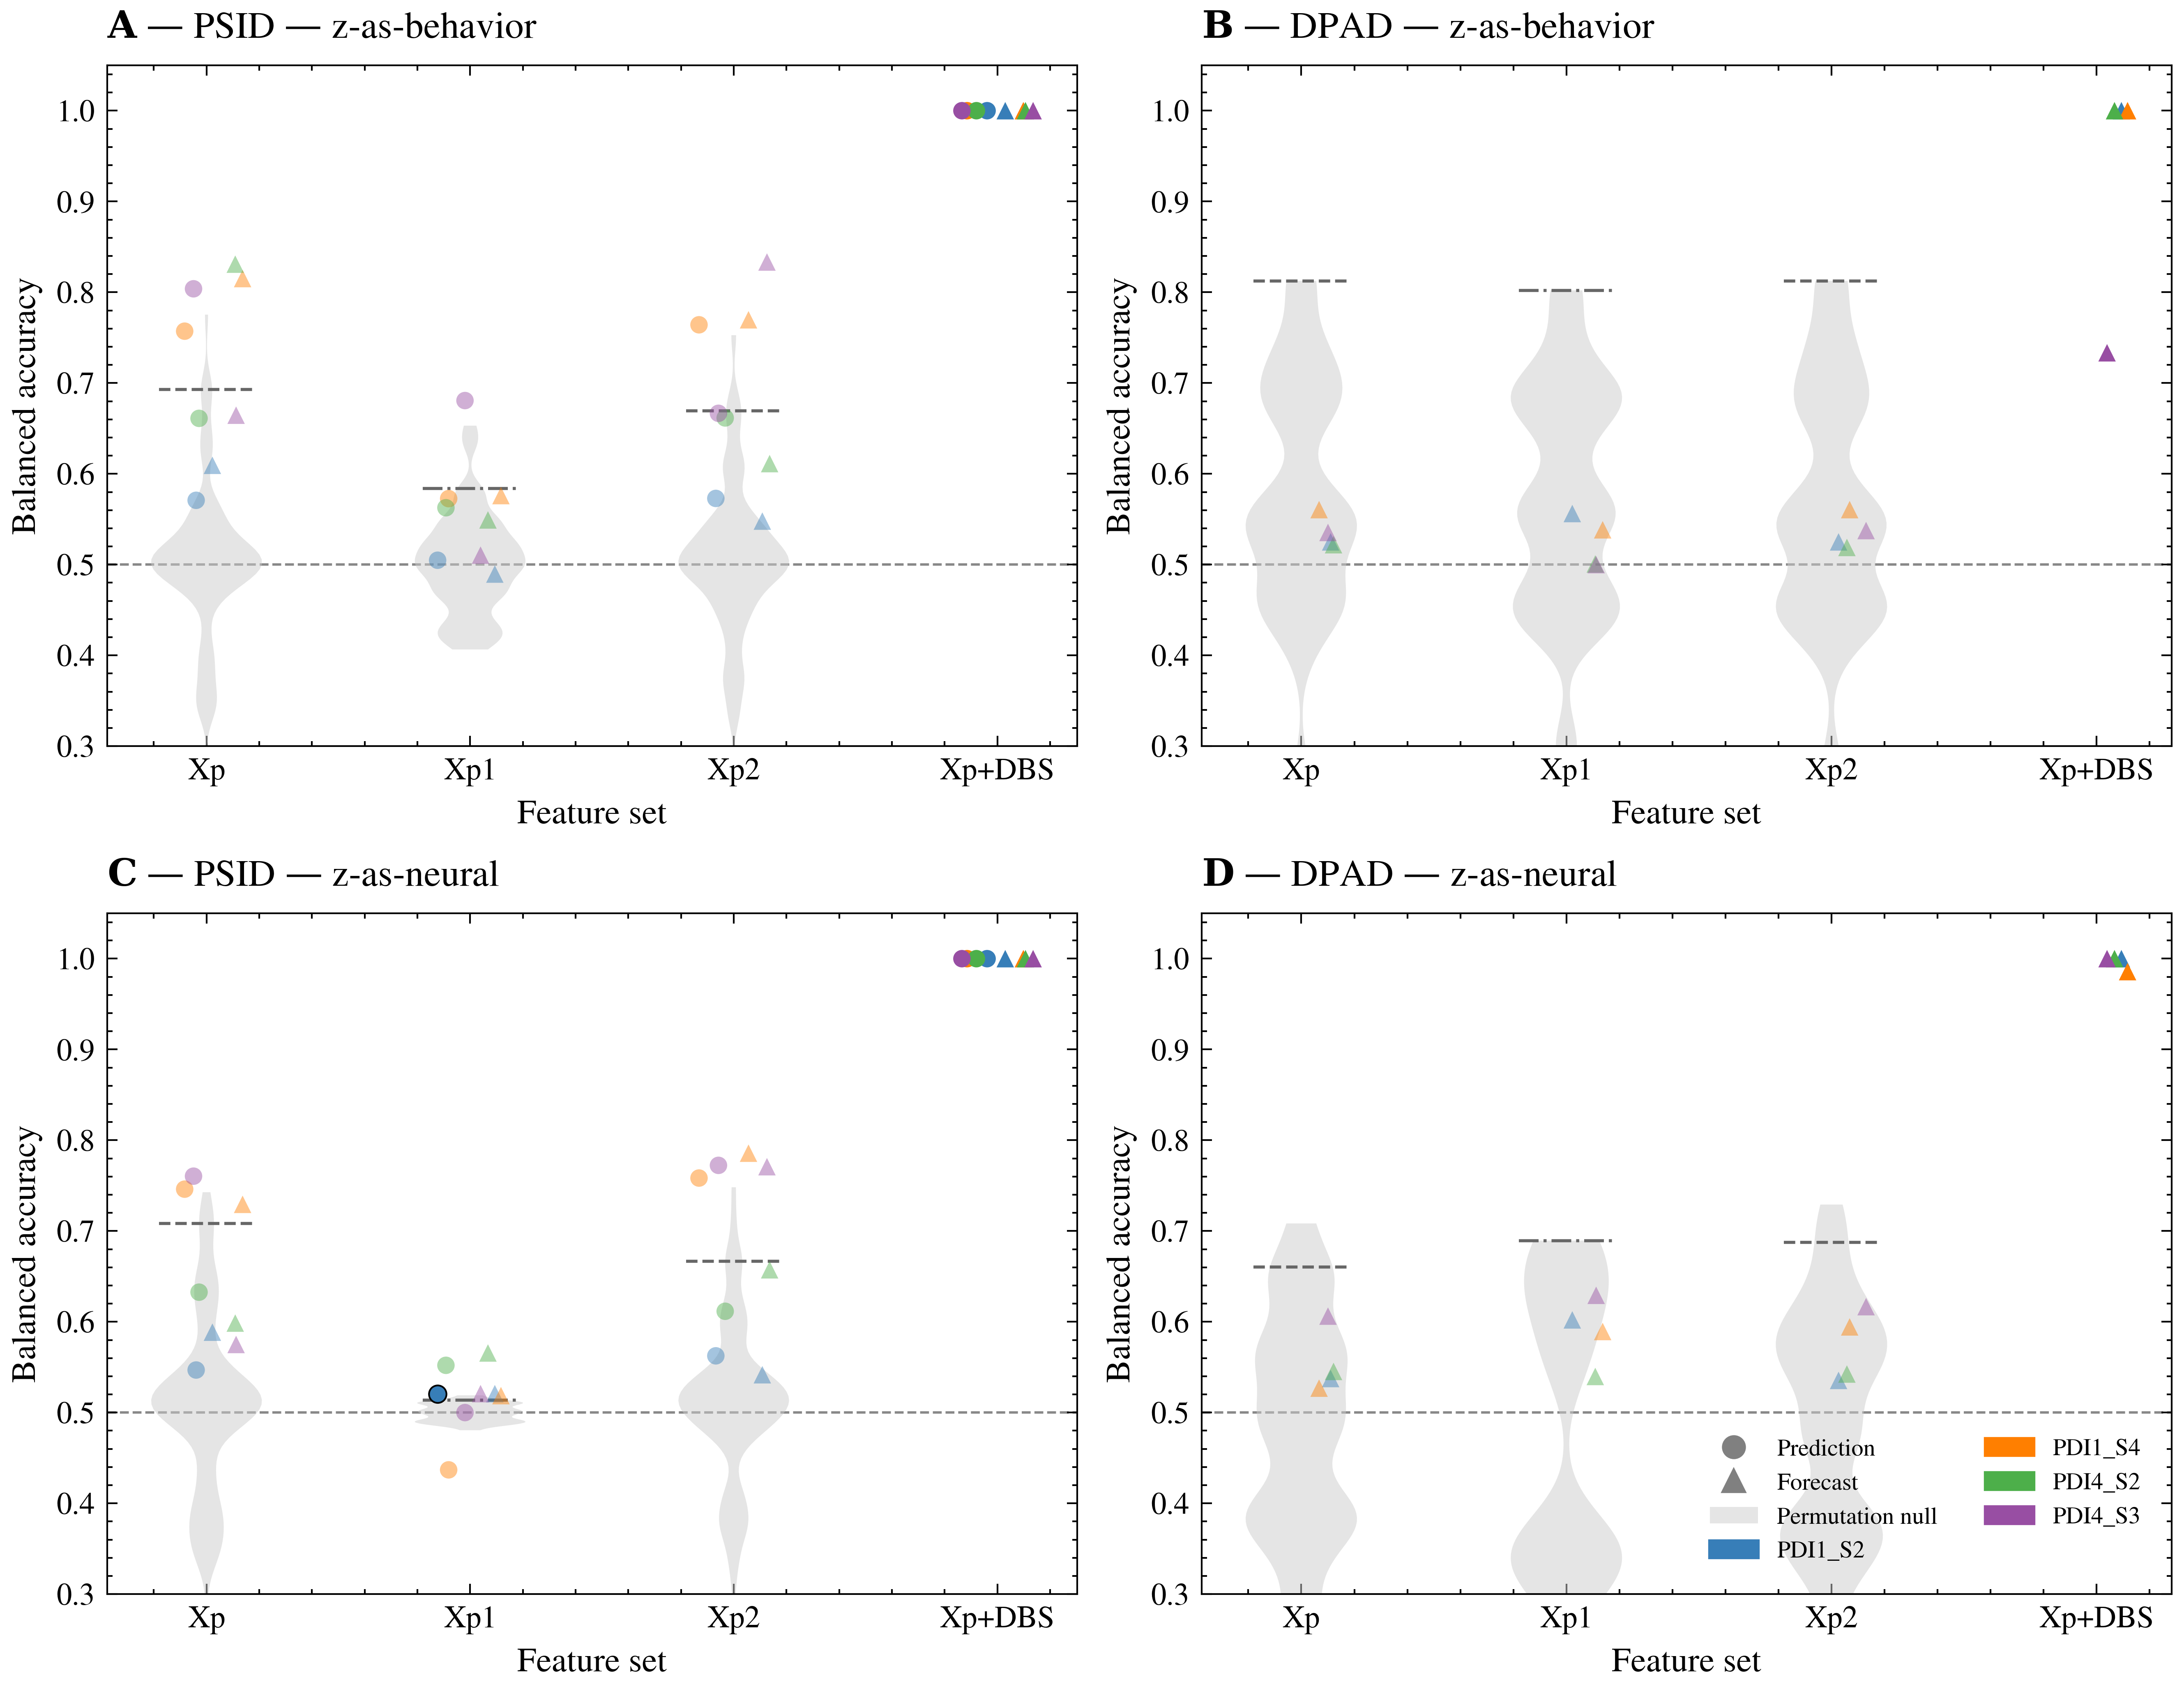

Fig 49 — DBS classification balanced accuracy. 2x2: rows=z-as-behavior/z-as-neural, cols=PSID/DPAD. x-axis: feature group (Xp / Xp1 / Xp2 / Xp+DBS). Circles=prediction, triangles=forecast (best h/m). Filled + black edge = p<0.05; faded = n.s. All results non-significant except Xp+DBS control.
CSV: table_049_classification.csv


In [17]:
render_cls_figure(OUT / "fig_049_classification_prediction.png")
print(
    "Fig 49 — DBS classification balanced accuracy. "
    "2x2: rows=z-as-behavior/z-as-neural, cols=PSID/DPAD. "
    "x-axis: feature group (Xp / Xp1 / Xp2 / Xp+DBS). "
    "Circles=prediction, triangles=forecast (best h/m). "
    "Filled + black edge = p<0.05; faded = n.s. All results non-significant except Xp+DBS control."
)

# Appendix CSV
table_path = OUT / "table_049_classification.csv"
with open(table_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["panel", "session", "feature", "model", "mode", "balanced_accuracy", "perm_pvalue", "best_h_m"])
    for pt in cls_points:
        sess_key = f"{pt.participant_label}_{pt.session_label}"
        mode = _mode_from_session_label(pt.session_label)
        w.writerow([
            "prediction", sess_key, pt.group, pt.model_label, mode,
            f"{pt.balanced_accuracy:.4f}" if np.isfinite(pt.balanced_accuracy) else "",
            f"{pt.permutation_pvalue:.4f}" if pt.permutation_pvalue is not None else "",
            "",
        ])
    for src_dict, model in [(forecast_bests_psid, "PSID"), (forecast_bests_dpad, "DPAD")]:
        for (sess, grp), (ba, hm, pval, _pscores) in src_dict.items():
            mode = _mode_from_session_label(sess)
            w.writerow([
                "forecast", sess, grp, model, mode,
                f"{ba:.4f}" if np.isfinite(ba) else "",
                f"{pval:.4f}" if pval is not None else "",
                hm or "",
            ])
print(f"CSV: {table_path.name}")

## Fig 49a: Confusion matrix grids — 4 figures (pipeline × experiment)

4 sessions × 4 feature groups each. One figure per pipeline (PSID, DPAD) × experiment
(ECoG & Tracing Kinematics; ECoG & Laplacian LFP). Row-normalized (rows = true class).

In [18]:
def _draw_confusion_cell(ax, cm: Optional[np.ndarray], *, title: str, color: str):
    if cm is None:
        ax.add_patch(
            plt.Rectangle(
                (0, 0),
                1,
                1,
                facecolor="#EEEEEE",
                edgecolor="#BBBBBB",
                hatch="///",
                linewidth=0.5,
            )
        )
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=7)
        return
    # Reorient: sklearn order [off=0, on=1] -> flip so on is top row.
    cm_oriented = cm[::-1, ::-1]
    row_sums = cm_oriented.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    norm_cm = cm_oriented / row_sums
    base_rgba = np.asarray(to_rgba(color))
    rgba = np.zeros((2, 2, 4))
    for i in range(2):
        for j in range(2):
            a = float(np.clip(norm_cm[i, j], 0, 1))
            rgba[i, j, :3] = base_rgba[:3]
            rgba[i, j, 3] = 0.15 + 0.75 * a
    ax.imshow(rgba, aspect="equal", interpolation="nearest")
    for i in range(2):
        for j in range(2):
            txt_color = "white" if norm_cm[i, j] > 0.55 else "#222222"
            ax.text(
                j,
                i,
                f"{norm_cm[i, j]:.2f}\n({int(cm_oriented[i, j])})",
                ha="center",
                va="center",
                fontsize=6,
                color=txt_color,
            )
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["ON", "OFF"], fontsize=6)
    ax.set_yticklabels(["ON", "OFF"], fontsize=6)
    ax.set_title(title, fontsize=7)

In [19]:
def _confusion_grid(pipe: str = "psid", mode: str = "behavioral") -> Optional[plt.Figure]:
    """4×4 confusion matrix grid for one pipeline × experiment combination."""
    mode_sessions = [sk for sk in session_keys if _mode_from_session_label(sk) == mode]
    if not mode_sessions:
        return None

    # PSID classifies from prediction latent states (Xp); DPAD from forecast states (Xf).
    if pipe == "psid":
        group_to_src = {"xp": "Xp", "xp_1": "Xp_1", "xp_2": "Xp_2", "xp_with_dbs": "Xp_with_dbs"}
    else:
        group_to_src = {"xp": "Xf", "xp_1": "Xf_1", "xp_2": "Xf_2", "xp_with_dbs": "Xf_with_dbs"}

    variant_map: Dict[str, str] = {}
    for v in _sweep_df["variant"].unique():
        if not v.endswith("_dbs_both") or not v.startswith(pipe):
            continue
        exp_type, participant, session, _ = _parse_variant_meta(v)
        if participant is None:
            continue
        sess_label = session if exp_type == "behavioral" else f"{session} (lap)"
        sk = f"{participant}_{sess_label}"
        if sk not in variant_map:
            variant_map[sk] = v

    n_rows, n_cols = len(mode_sessions), len(features)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(1.4 * n_cols + 0.6, 1.4 * n_rows + 0.6)
    )
    axes = np.atleast_2d(axes)
    drew_any = False
    color = COLOR_PSID if pipe == "psid" else COLOR_DPAD

    for ri, sk in enumerate(mode_sessions):
        variant = variant_map.get(sk)
        for ci, feat in enumerate(features):
            ax = axes[ri, ci]
            cm = None
            if variant:
                sub_src = group_to_src[feat]
                cm = _cm_from_sweep(variant, sub_src, pipe)
            title = f"{GROUP_SHORT[feat]}" if ri == 0 else ""
            _draw_confusion_cell(ax, cm, title=title, color=color)
            if cm is not None:
                drew_any = True
        axes[ri, 0].set_ylabel(sk.replace(" (lap)", ""), fontsize=7)

    exp_label = "ECoG & Laplacian LFP" if mode == "laplacian" else "ECoG & tracing kinematics"
    cls_note = "prediction states (Xp)" if pipe == "psid" else "forecast states (Xf)"
    fig.suptitle(
        f"DBS confusion matrices — {pipe.upper()} {cls_note}, {exp_label}",
        fontsize=9, y=0.995,
    )
    fig.tight_layout()
    return fig if drew_any else None

/tmp/ipykernel_1220825/4246430450.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


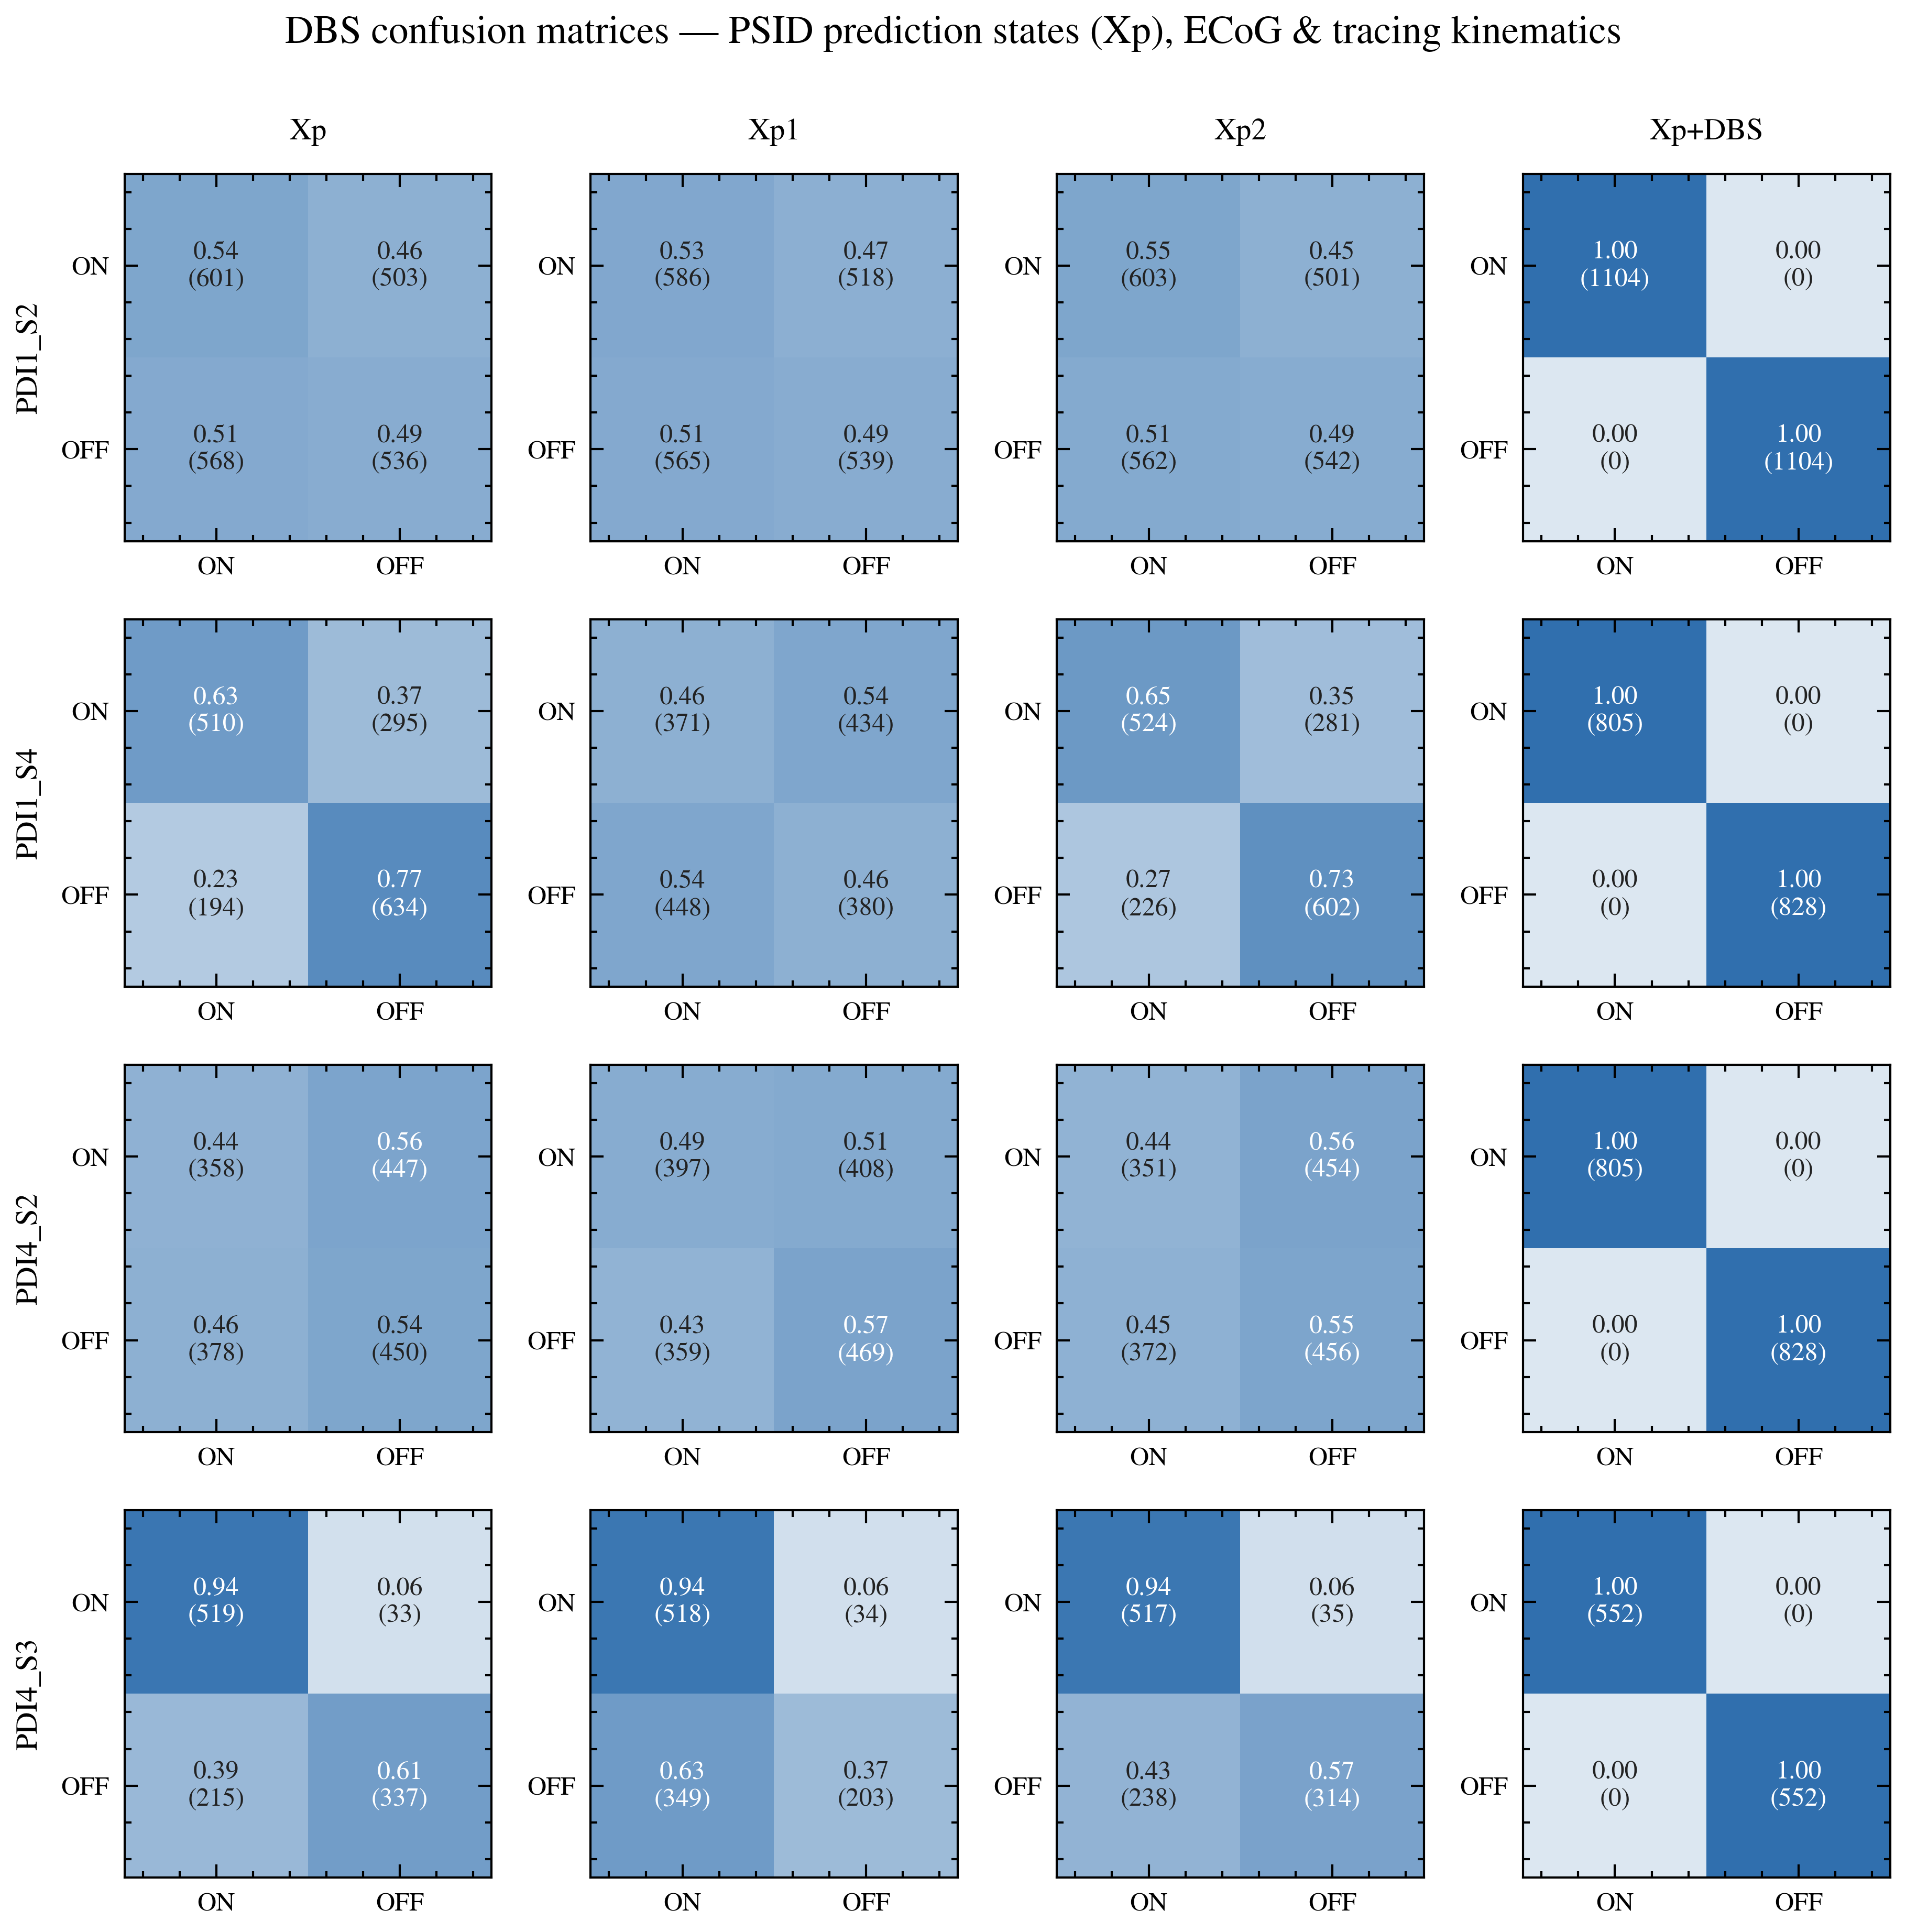

Fig 49a (psid_beh) — DBS confusion matrices: PSID, behavioral.


/tmp/ipykernel_1220825/4246430450.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


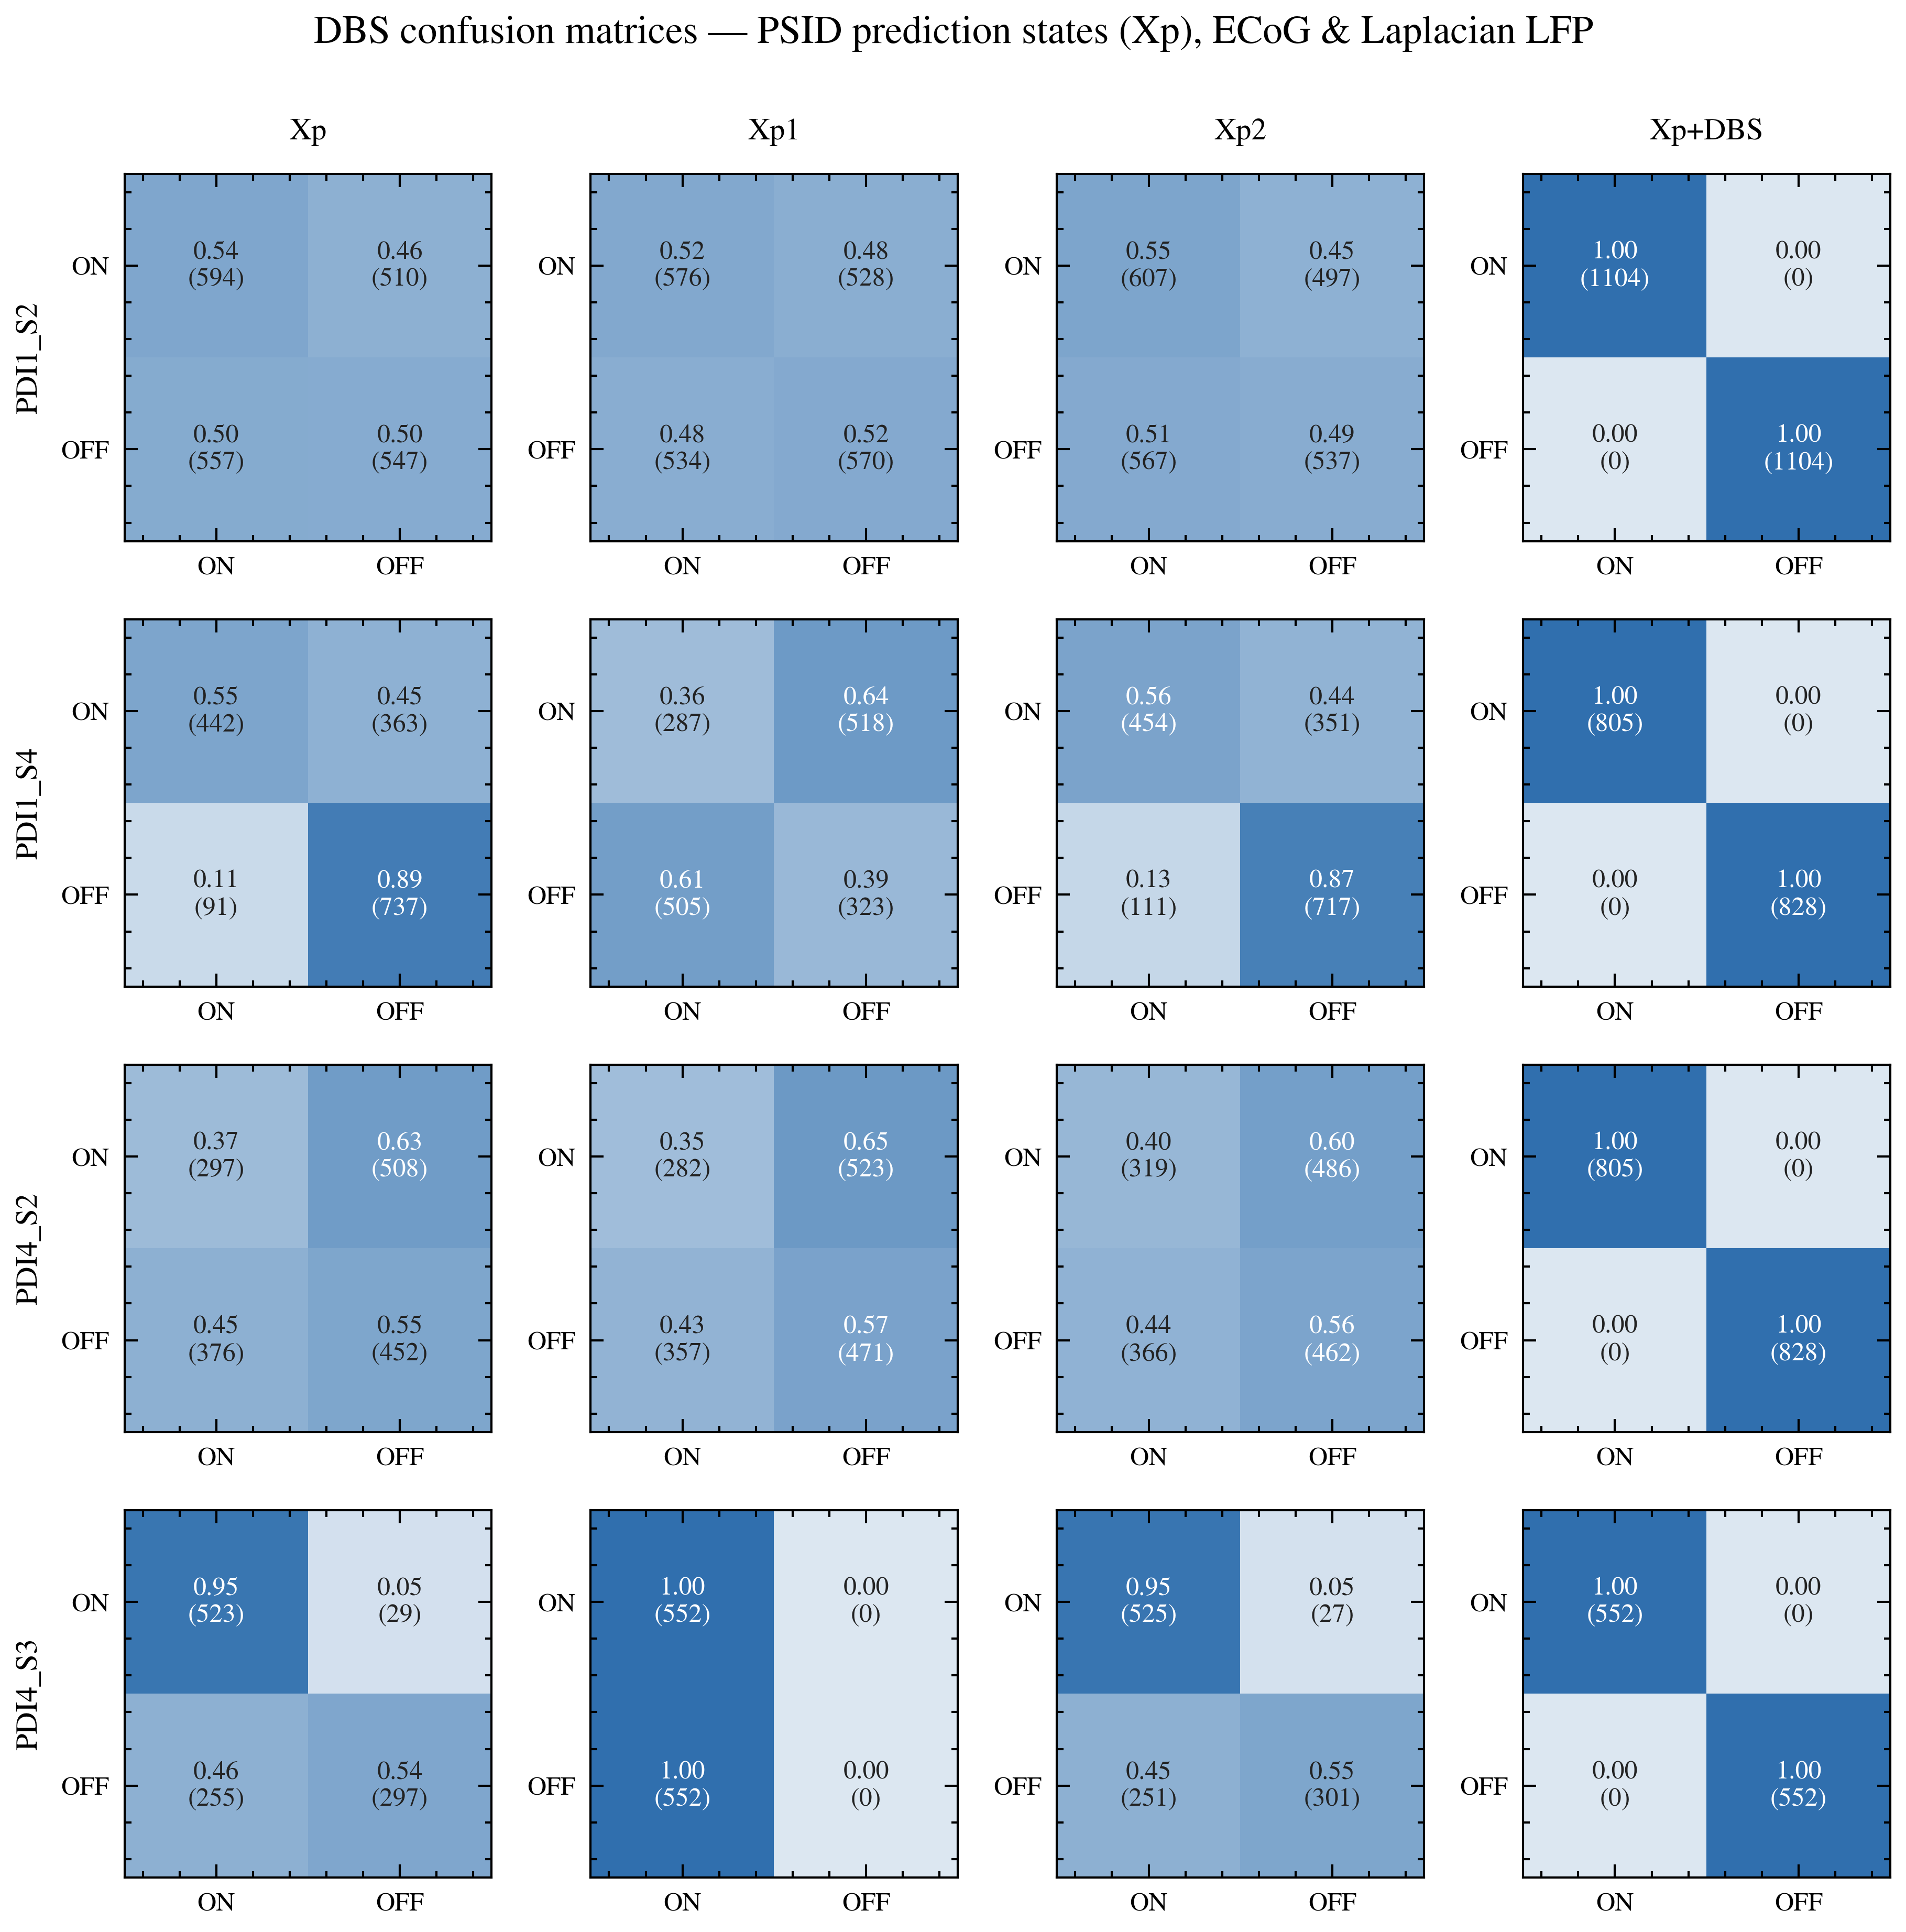

Fig 49a (psid_lap) — DBS confusion matrices: PSID, laplacian.


/tmp/ipykernel_1220825/4246430450.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


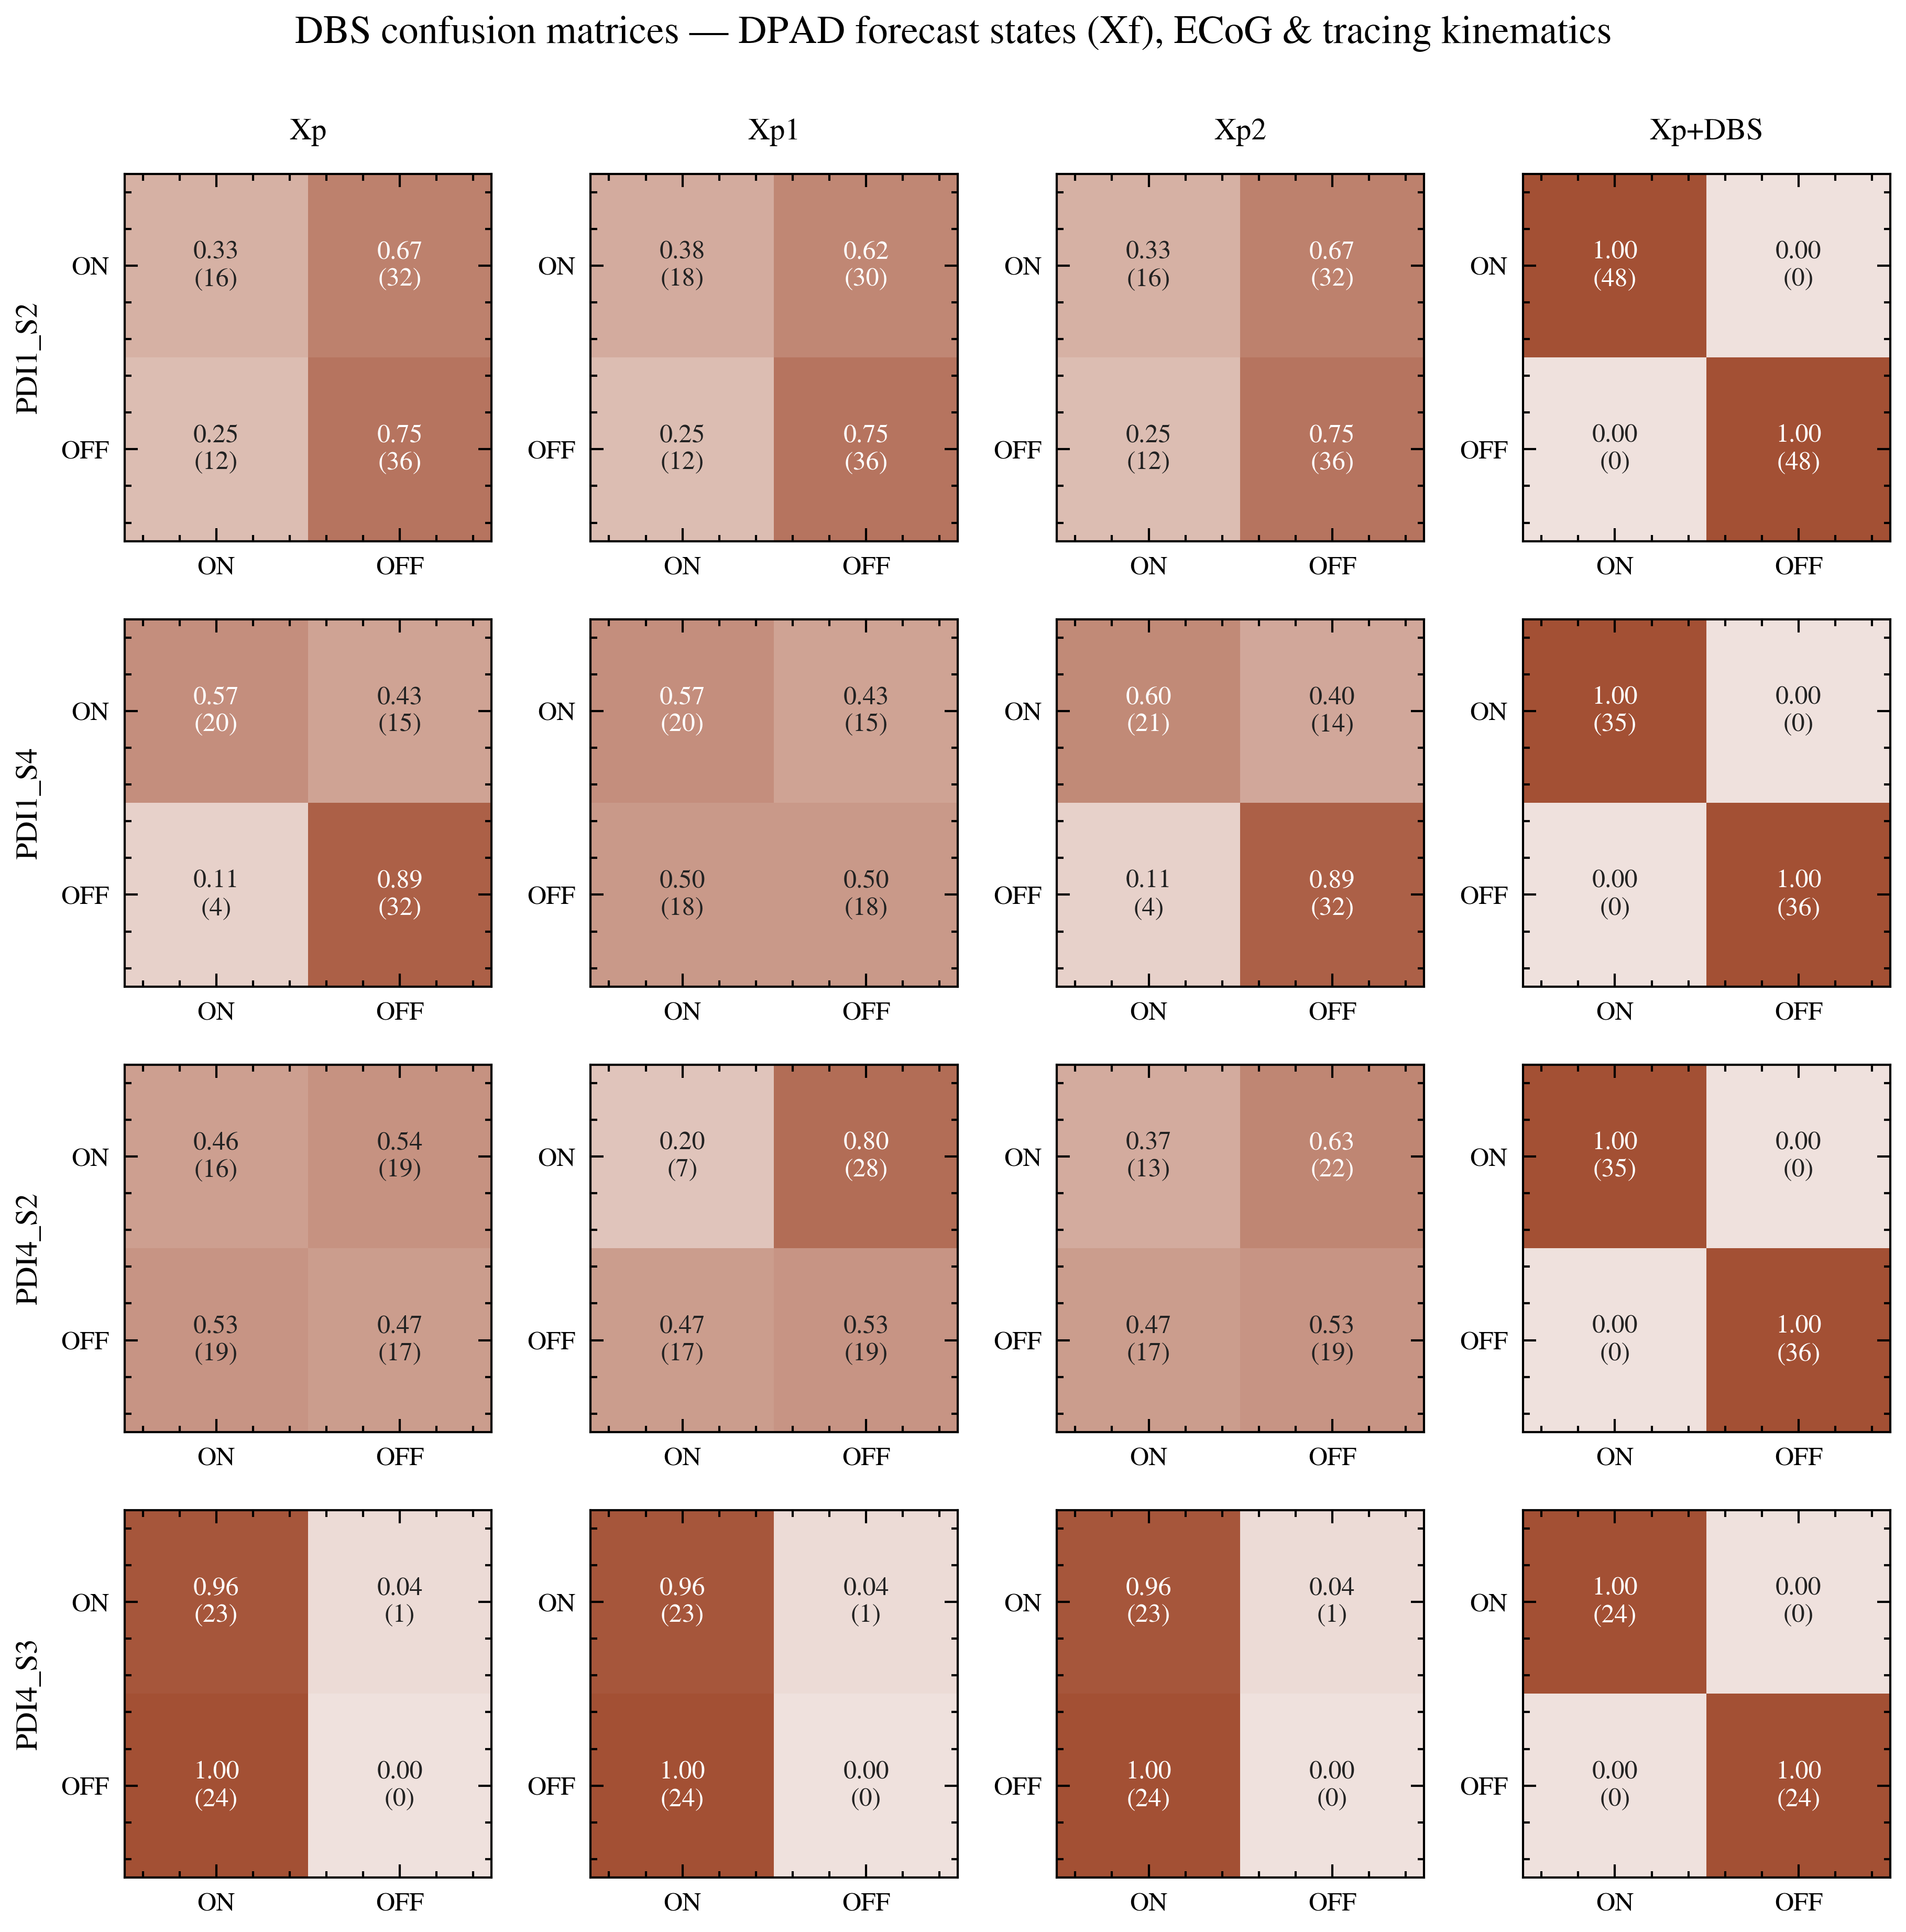

Fig 49a (dpad_beh) — DBS confusion matrices: DPAD, behavioral.


/tmp/ipykernel_1220825/4246430450.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


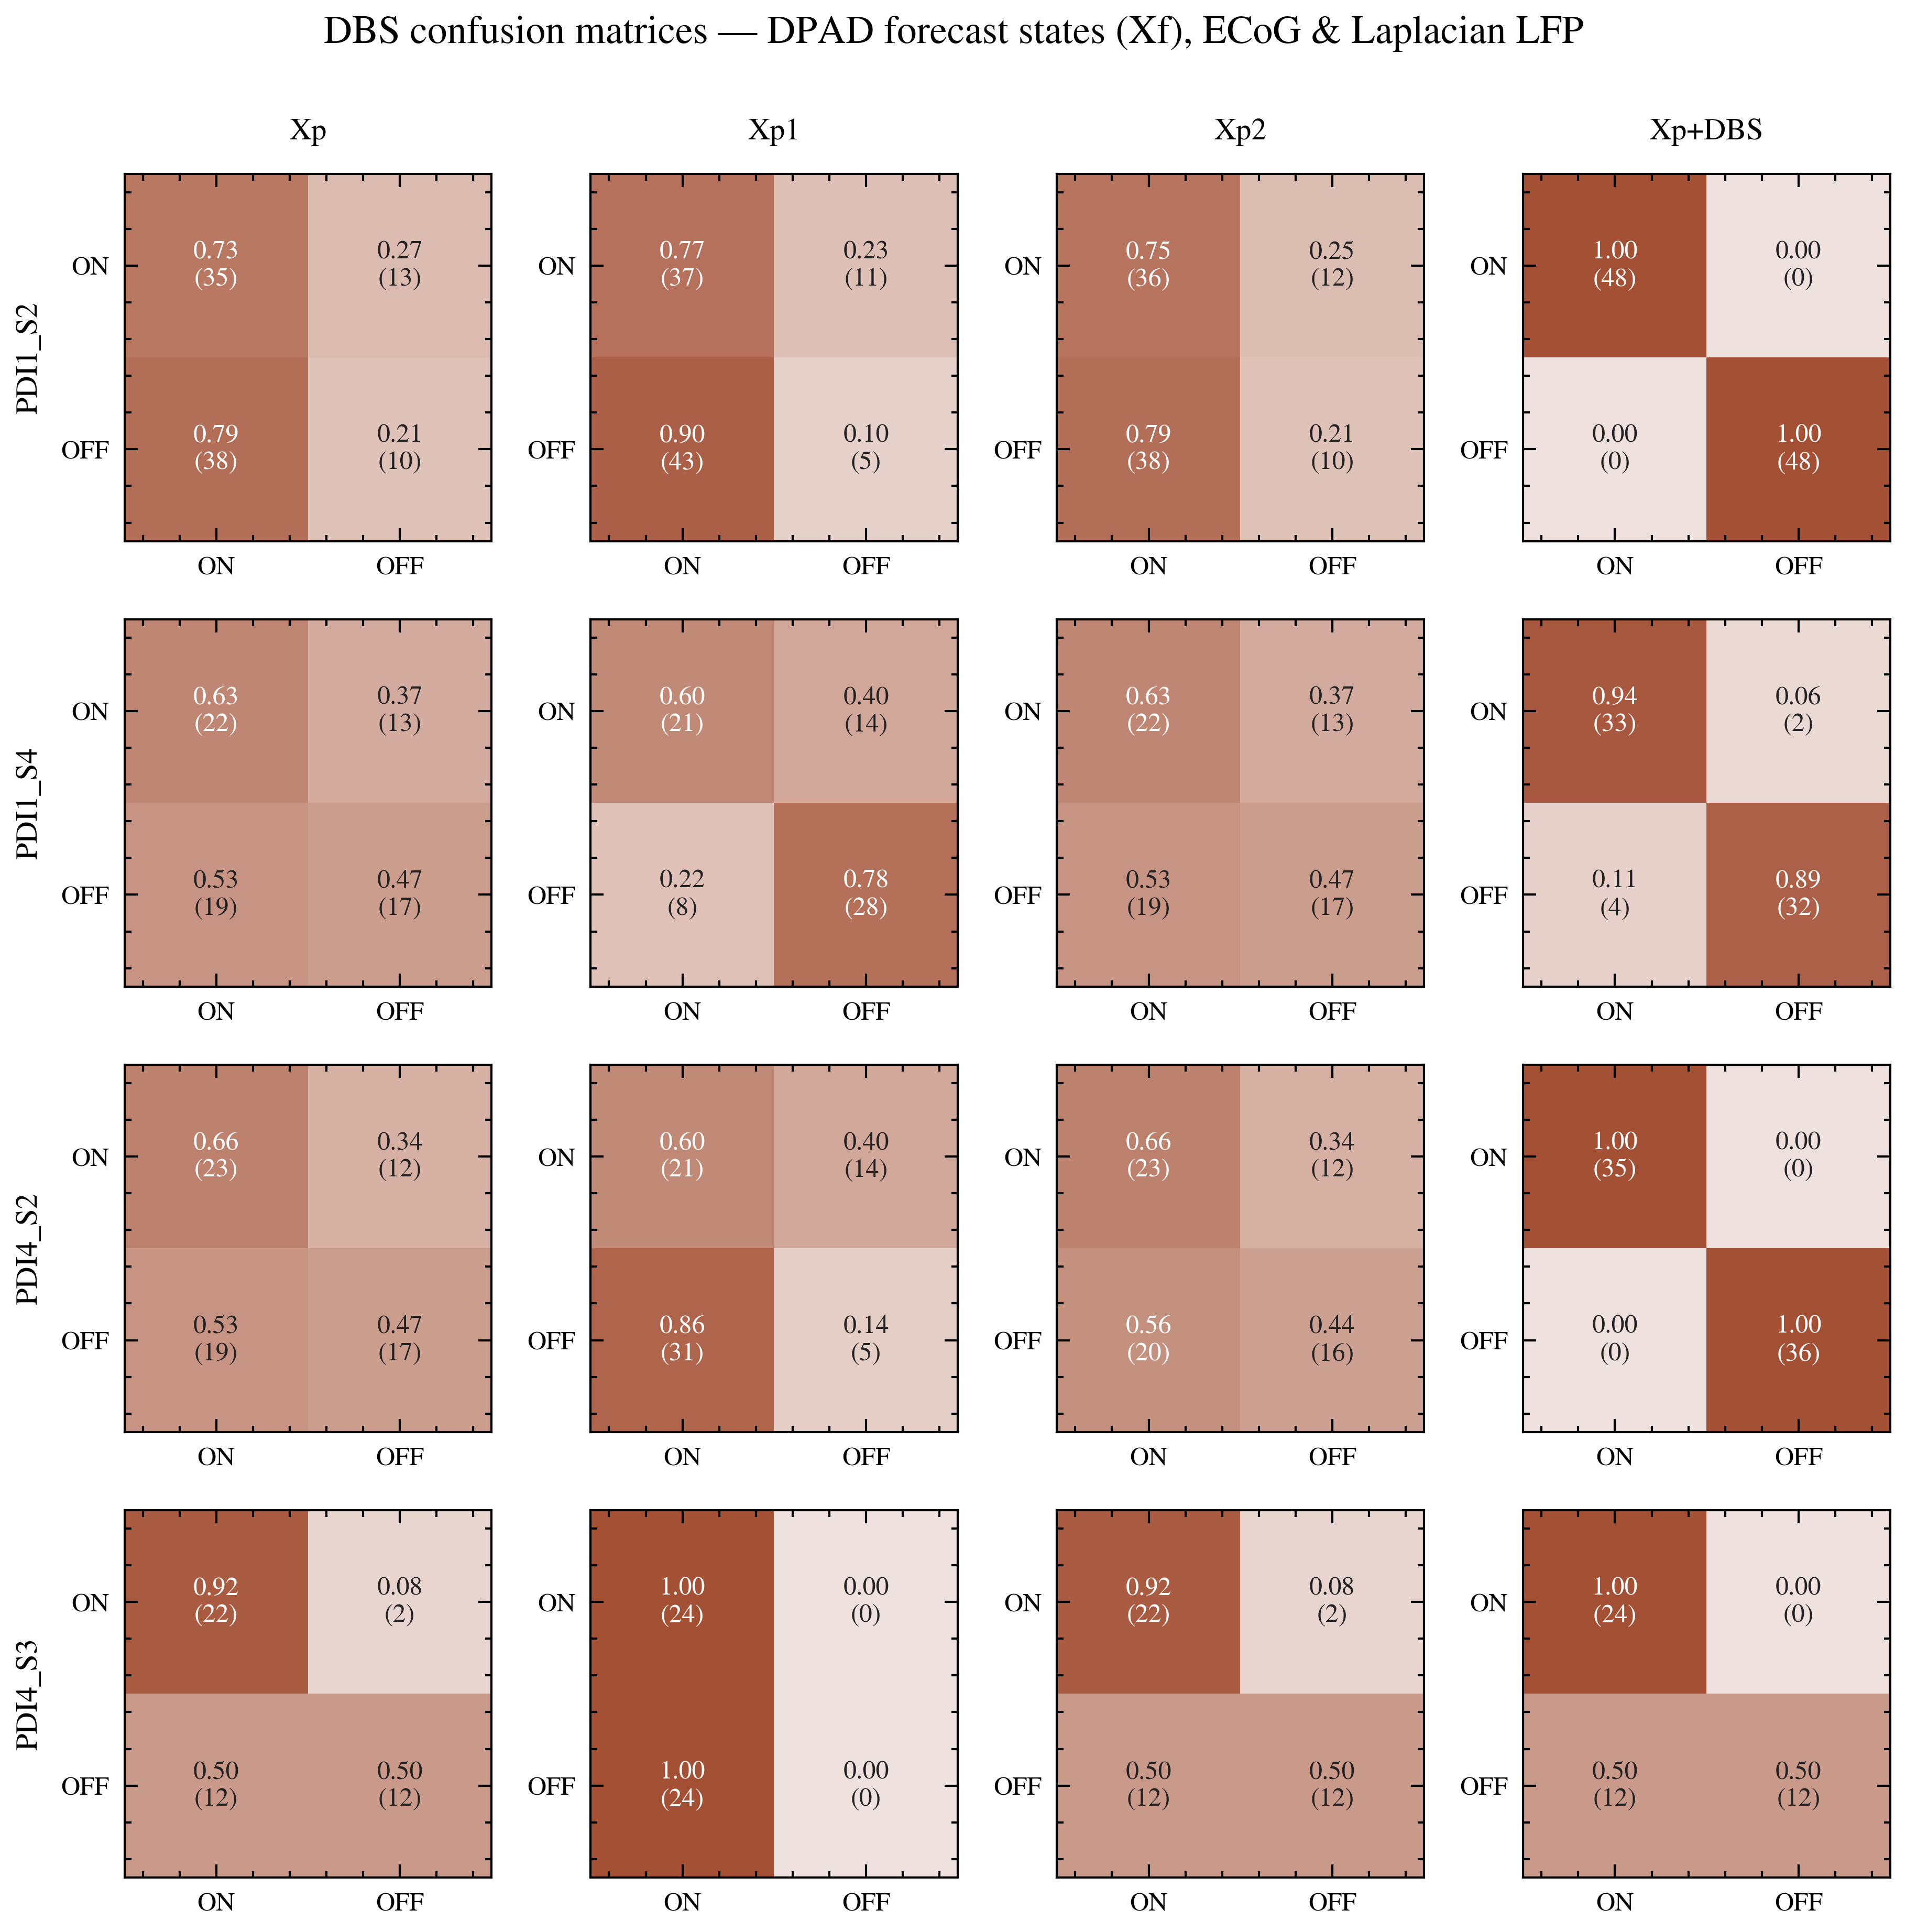

Fig 49a (dpad_lap) — DBS confusion matrices: DPAD, laplacian.


In [20]:
for pipe, mode, suffix in [
    ("psid", "behavioral", "psid_beh"),
    ("psid", "laplacian", "psid_lap"),
    ("dpad", "behavioral", "dpad_beh"),
    ("dpad", "laplacian", "dpad_lap"),
]:
    fig = _confusion_grid(pipe=pipe, mode=mode)
    if fig is not None:
        fname = f"fig_049a_confusion_{suffix}.png"
        fig.savefig(str(OUT / fname))
        plt.show()
        print(f"Fig 49a ({suffix}) — DBS confusion matrices: {pipe.upper()}, {mode}.")
    else:
        print(f"No data: pipe={pipe}, mode={mode}")

## Archived: ROC curves (fig_050, fig_050b)

Results non-significant; figures moved to `thesis_figures/sec5/archive/`.

## Fig 51: Flipped classification — cross-condition forecast (1×2 dot plot)

Cross-condition forecast classification (mode=forecast, flipped=True). PSID only.

x-axis: feature group (Xp | Xp1 | Xp2 | Xp+DBS). Dots colored by session. Filled dot with black edge = p < 0.05; faded = n.s.

Best (h, m) selected per (session, feature) from flipped=True forecast sweep.

**Key finding:** PDI1_S4, PDI4_S2, PDI4_S3 reach p=0.002 (minimum with 500 permutations) for Xp and Xp2 in both experiments (BA ~0.76–0.89). PDI1_S2 is n.s. — the only exception. Cross-condition generalization works for 3 of 4 sessions.

/tmp/ipykernel_1220825/200439110.py:113: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


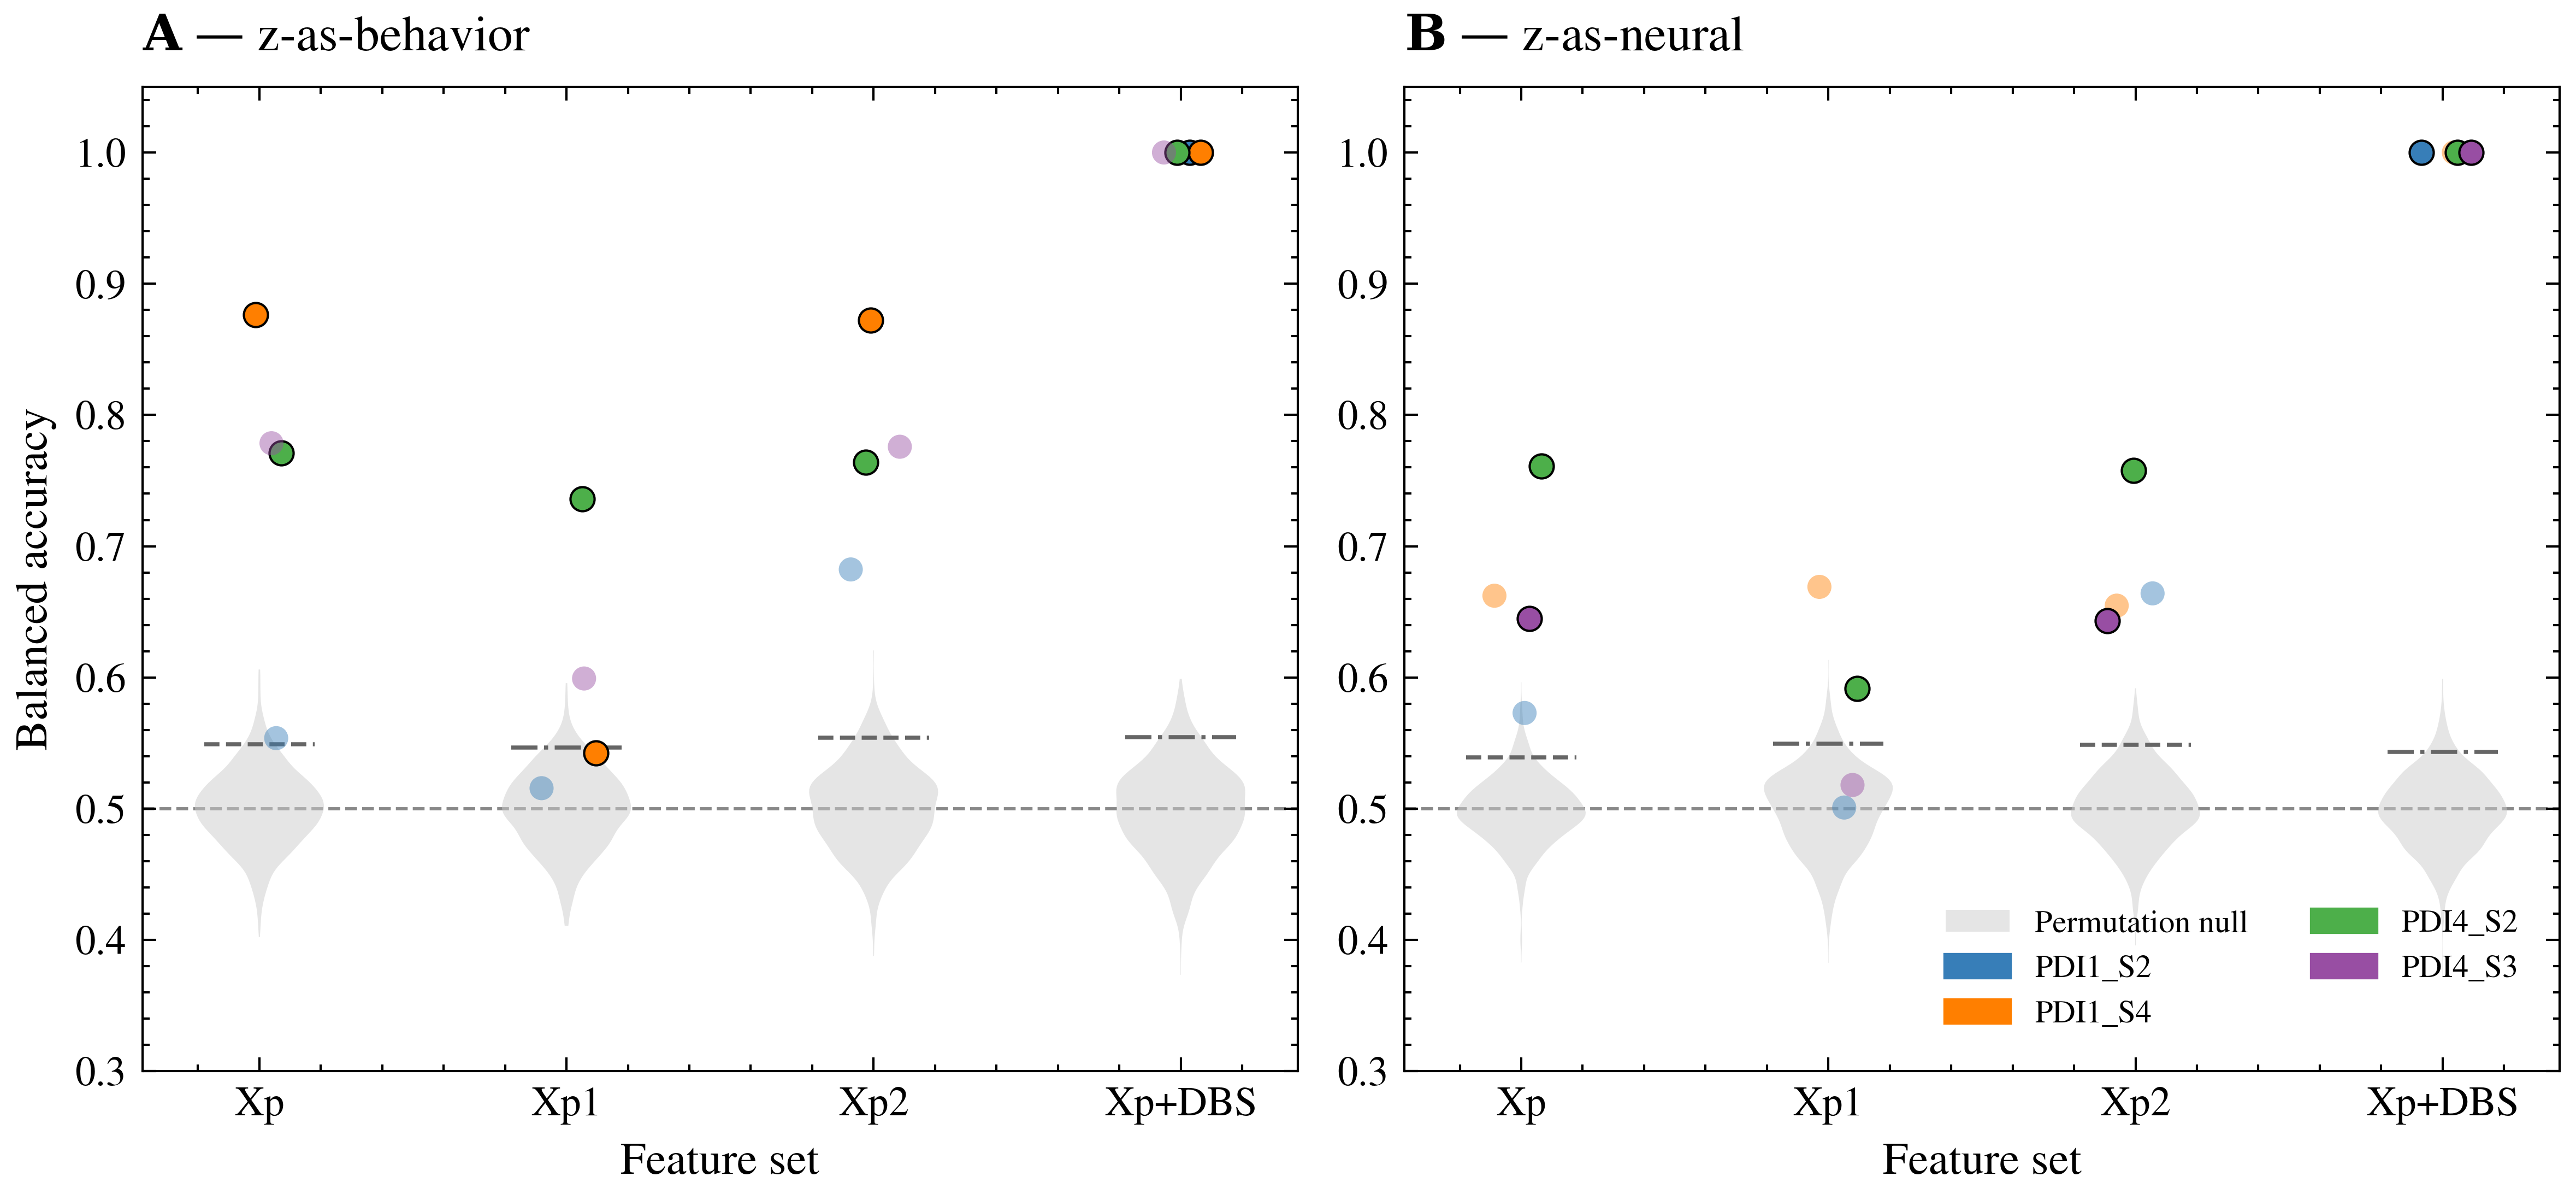

Fig 51 — Cross-condition (flipped) forecast classification, PSID only. 1x2: z-as-behavior (A), z-as-neural (B). Gray violin = permutation null; tick = 95th percentile. Filled dot = p<0.05 (p=0.002 for PDI1_S4/PDI4_S2/PDI4_S3 Xp/Xp2); faded = n.s.


In [21]:
def build_flipped_bests_from_parquet() -> Dict[Tuple[str, str], Tuple[float, str, Optional[float], Optional[Tuple]]]:
    """Best ba_at_score per (session_key, feature_group) for flipped=True PSID forecast."""
    if _sweep_df.empty:
        return {}
    df = _sweep_df[
        (_sweep_df["mode"] == "forecast")
        & (_sweep_df["flipped"] == True)
        & (_sweep_df["sub_source"].isin(_FCST_SRC_TO_GROUP.keys()))
        & (_sweep_df["variant"].str.contains("_dbs_both$"))
        & (_sweep_df["pipeline"] == "psid")
    ]
    best = df.sort_values("ba_at_score", ascending=False).drop_duplicates(
        subset=["variant", "sub_source"]
    )
    out: Dict[Tuple[str, str], Tuple[float, str, Optional[float], Optional[Tuple]]] = {}
    for _, row in best.iterrows():
        exp_type, participant, session, _ = _parse_variant_meta(row["variant"])
        if participant is None:
            continue
        group = _FCST_SRC_TO_GROUP[row["sub_source"]]
        sess_label = session if exp_type == "behavioral" else f"{session} (lap)"
        sess_key = f"{participant}_{sess_label}"
        pval = float(row["p_value"]) if pd.notna(row["p_value"]) else None
        h_m = f"h{row['h_seconds']:g}_m{row['m_test_seconds']:g}"
        raw_scores = row.get("perm_scores")
        pscores = (
            tuple(float(v) for v in raw_scores)
            if raw_scores is not None and hasattr(raw_scores, "__len__") and len(raw_scores) > 0
            else None
        )
        out[(sess_key, group)] = (float(row["ba_at_score"]), h_m, pval, pscores)
    return out


flipped_bests = build_flipped_bests_from_parquet()

pooled_flip: Dict[Tuple[str, str, str], List] = {}
for (sess, grp), (ba, hm, pval, pscores) in flipped_bests.items():
    exp_mode = _mode_from_session_label(sess)
    pooled_flip.setdefault((grp, "PSID", exp_mode), []).append((sess, ba, pval, pscores))

def _rank_flip(e):
    base = e[0].replace(" (lap)", "")
    try:
        return list(SESSIONS).index(base)
    except ValueError:
        return 99

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.8))
rng_flip = np.random.default_rng(42)

for ax, exp_mode, letter, exp_label in zip(
    axes, ["behavioral", "laplacian"], ["A", "B"], ["z-as-behavior", "z-as-neural"]
):
    ax.axhline(0.5, color="#888888", linewidth=0.7, linestyle="--", zorder=1)

    for fi, feat in enumerate(features):
        entries = sorted(pooled_flip.get((feat, "PSID", exp_mode), []), key=_rank_flip)

        # Permutation null violin
        all_pscores = []
        for entry in entries:
            if entry[3] is not None:
                all_pscores.extend(entry[3])
        if all_pscores:
            parts = ax.violinplot(
                [all_pscores], positions=[fi], widths=0.42,
                showmeans=False, showextrema=False, showmedians=False,
            )
            for body in parts["bodies"]:
                body.set_facecolor("#CCCCCC")
                body.set_alpha(0.5)
                body.set_edgecolor("none")
                body.set_zorder(2)
            p95 = np.percentile(all_pscores, 95)
            ax.plot(
                [fi - 0.18, fi + 0.18], [p95, p95],
                color="#666666", linewidth=0.9, zorder=2,
            )

        n = len(entries)
        jitter = rng_flip.uniform(-0.10, 0.10, n) if n else np.array([])
        for j, entry in enumerate(entries):
            sess_key, ba, pval = entry[0], entry[1], entry[2]
            if not np.isfinite(ba):
                continue
            sess_color = SESSION_COLORS.get(sess_key.replace(" (lap)", ""), "#888888")
            sig = pval is not None and pval < 0.05
            ax.scatter(
                fi + jitter[j], ba, s=28, color=sess_color,
                alpha=1.0 if sig else 0.45,
                edgecolor="black" if sig else "none",
                linewidths=0.5, zorder=3,
            )

    ax.set_ylim(0.3, 1.05)
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels([GROUP_SHORT[f] for f in features])
    ax.set_xlabel("Feature set")
    panel_label(ax, letter, exp_label)

axes[0].set_ylabel("Balanced accuracy")

legend_handles = [
    Patch(facecolor="#CCCCCC", alpha=0.5, edgecolor="none", label="Permutation null"),
    Patch(color=SESSION_COLORS["PDI1_S2"], label="PDI1_S2"),
    Patch(color=SESSION_COLORS["PDI1_S4"], label="PDI1_S4"),
    Patch(color=SESSION_COLORS["PDI4_S2"], label="PDI4_S2"),
    Patch(color=SESSION_COLORS["PDI4_S3"], label="PDI4_S3"),
]
axes[1].legend(handles=legend_handles, fontsize=7, loc="lower right", ncol=2)

fig.tight_layout()
fig.savefig(str(OUT / "fig_051_flipped_classification.png"))
plt.show()

print(
    "Fig 51 — Cross-condition (flipped) forecast classification, PSID only. "
    "1x2: z-as-behavior (A), z-as-neural (B). "
    "Gray violin = permutation null; tick = 95th percentile. "
    "Filled dot = p<0.05 (p=0.002 for PDI1_S4/PDI4_S2/PDI4_S3 Xp/Xp2); faded = n.s."
)

## Archived: Fig 52 — prediction significance onset (t_cut sweep)

Results non-significant; figures moved to `thesis_figures/sec5/archive/`.

## Archived: Fig 52b — forecast horizon significance decay

Results non-significant; figures moved to `thesis_figures/sec5/archive/`.